# Установка необходимых пакетов и импорт библиотек

In [1]:
!pip3 install anndata
!pip3 install scanpy
!pip3 install matplotlib==3.1.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 24.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import pandas as pd
from tqdm.notebook import tqdm
import seaborn as sns; sns.set_theme()
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap

# Загрузка файлов

In [3]:
# список идентификаторов образцов из базы данных
gsm_list = [
            ('7017', '1395'),
            ('7018', '1396'),
            ('7019', '1398'),
            ('7020', '1458'),
            ('7021', '1459'),
            ('7022', '1539'),
            ('7023', '1540'),
            ('7024', '1541'),
            ('7025', '1542'),
            ('7026', '1544'),
            ('7027', '1545'),
            ('7028', '1546'),
            ('7029', '1646'),
            ('7030', '1647'),
            ('7031', '1648'),
            ('7032', '1649'),
            ('7033', '1751'),
            ('7034', '1753'),
            ('7035', '1792'),
            ('7036', '1793'),
            ('7037', '1795'),
]


In [4]:
for gsm, ab in gsm_list:

  # Паттерн ссылки
  #ftp://ftp.ncbi.nlm.nih.gov/geo/samples/
  #GSM2787nnn/                    # папка для GSM2787xxx
  #GSM278{gsm}/                   # папка конкретного образца
  #suppl/                         # папка с дополнительными файлами
  #GSM278{gsm}_AB{ab}.txt.gz      # имя файла

  url = f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM278{gsm}/suppl/GSM278{gsm}_AB{ab}.txt.gz"

  # wget - команда для скачивания файлов
  # -c - продолжать прерванную загрузку
  # -nv - выводить минимум информации

  !wget -c -nv {url}

  # gzip - команда для работы с gzip-архивами
  # -f - перезаписывать существующие файлы
  # -d - распаковать

  !gzip -f -d GSM278{gsm}_AB{ab}.txt.gz

2025-12-13 19:46:08 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787017/suppl/GSM2787017_AB1395.txt.gz [484276/484276] -> "GSM2787017_AB1395.txt.gz" [1]
2025-12-13 19:46:10 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787018/suppl/GSM2787018_AB1396.txt.gz [398303/398303] -> "GSM2787018_AB1396.txt.gz" [1]
2025-12-13 19:46:12 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787019/suppl/GSM2787019_AB1398.txt.gz [490402/490402] -> "GSM2787019_AB1398.txt.gz" [1]
2025-12-13 19:46:14 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787020/suppl/GSM2787020_AB1458.txt.gz [393417/393417] -> "GSM2787020_AB1458.txt.gz" [1]
2025-12-13 19:46:16 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787021/suppl/GSM2787021_AB1459.txt.gz [482002/482002] -> "GSM2787021_AB1459.txt.gz" [1]
2025-12-13 19:46:18 URL:https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM2787nnn/GSM2787022/suppl/GSM2787022_AB1539.txt.gz [348159/348159] -> "GSM2787022_AB1539.txt.

# Объединение файлов в одну матрицу

In [5]:
# список для хранения df
all_data = []

for gsm, ab in gsm_list:

    filename = f"GSM278{gsm}_AB{ab}.txt"
    df = pd.read_csv(filename, sep='\t')

    all_data.append(df)

# объединяю все df
counts = pd.concat(all_data, axis=1) # получается матрица
counts

,W291665,W291666,W291667,W291668,W291669,W291670,W291671,W291672,W291673,W291674,...,W432007,W432008,W432009,W432010,W432011,W432012,W432013,W432014,W432015,W432016
0610005C13Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007C21Rik,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007L01Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
0610007P08Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007P14Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
snoZ159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ178,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ39,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ40,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Экспрессия маркерных генов

In [6]:
# чтение файла от авторов статьи

# первая строка в файле не корректна для заголовка dataframe
df = pd.read_csv('/content/thymus_epithel_clusts.txt', sep='\t',
                 header=None,
                 skiprows=1)  # пропустить первую строку файла
df.columns = ['cell_id', 'clust', 'group'] # задаю колонки
df = df.set_index('cell_id')               # делаю первую колонку индексом
df

,clust,group
cell_id,,
W160351,2,mTEC-IV
W160352,32,mTEC-III
W160353,35,mTEC-II
W160357,34,mTEC-II
W160358,3,mTEC-IV
...,...,...
W271100,30,mTEC-II
W271101,23,mTEC-III
W271102,35,mTEC-II


In [7]:
markers = ['Ctsl', 'Psmb11', 'Prss16', 'Ascl1', 'Sox4', 'Ccl21a', 'Apoe', 'Ly6a', 'Ccl21c', 'Aire', 'Hdc', 'Ubd', \
           'Cd52', 'Ccl20', 'Serpinb6a', 'Ly6d', 'Pigr', 'Car8', 'Lcn2', 'Trpm5', 'Avil', 'Gnb3', 'Lrmp']

In [20]:
# фильрация counts

# нахожу пересечения клеток
# df.index - индекс df (cписок id клеток, которые использовали авторы статьи)
# counts.columns - названия колонок counts (cписок id клеток, скаченных из GEO)
intersection = set(df.index).intersection(set(counts.columns))

# фильтрую матрицу
counts_filtered = counts.loc[:, list(intersection)] # взять все строки и только те столбцы, которые перечислены в intersection

counts_filtered

,W291739,W340324,W291907,W378801,W431279,W416553,W379137,W379175,W314757,W378807,...,W431410,W431618,W292292,W340791,W292266,W339800,W378683,W340302,W379145,W292282
0610005C13Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007C21Rik,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
0610007L01Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
0610007P08Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0610007P14Rik,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
snoZ159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ178,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ39,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snoZ40,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# normalization (TPM (transcripts per million), FPKM (fragments per kilobase of transcript per million fragments mapped),
# CPM = (counts / total_counts_in_cell) * 1,000,000

# Сумма по каждой клетке (столбцу)
cell_totals = counts_filtered.sum(axis=0)
# Нормализация
tpm_matrix = counts_filtered.div(cell_totals) * 1e6  # 1e6 = 1,000,000
tpm_matrix

,W291739,W340324,W291907,W378801,W431279,W416553,W379137,W379175,W314757,W378807,...,W431410,W431618,W292292,W340791,W292266,W339800,W378683,W340302,W379145,W292282
0610005C13Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
0610007C21Rik,0.0,0.0,0.0,0.0,0.0,0.0,108.119797,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,560.852496,0.0,0.0,0.0,0.0
0610007L01Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,848.896435,0.000000,0.000000,0.0,0.0,0.0,0.0
0610007P08Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
0610007P14Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,1046.025105,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
snoZ159,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
snoZ178,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
snoZ39,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
snoZ40,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [22]:
# Отбираю маркерные гены
counts = tpm_matrix.loc[markers, :]
counts

,W291739,W340324,W291907,W378801,W431279,W416553,W379137,W379175,W314757,W378807,...,W431410,W431618,W292292,W340791,W292266,W339800,W378683,W340302,W379145,W292282
Ctsl,383.435583,1044.386423,0.000000,5323.868678,389.559797,0.000000,27029.949184,0.000000,622.665006,696.864111,...,0.000000,0.000000,0.000000,0.000000,1046.025105,0.000000,676.361177,0.000000,0.000000,0.000000
Psmb11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1405.557358,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Prss16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12541.896421,108.766587,415.110004,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,392.927308,0.000000
Ascl1,0.000000,0.000000,0.000000,3253.475303,649.266329,2514.668902,0.000000,0.000000,622.665006,6968.641115,...,0.000000,0.000000,0.000000,3395.585739,2615.062762,0.000000,338.180588,0.000000,0.000000,0.000000
Sox4,3067.484663,1044.386423,0.000000,0.000000,0.000000,5029.337804,0.000000,0.000000,830.220008,1393.728223,...,666.666667,1310.370648,0.000000,848.896435,2615.062762,0.000000,0.000000,0.000000,0.000000,3565.062389
Ccl21a,383.435583,3655.352480,0.000000,5323.868678,0.000000,0.000000,0.000000,108.766587,3320.880033,5574.912892,...,0.000000,0.000000,788.332676,0.000000,3138.075314,0.000000,3043.625296,2341.920375,785.854617,4456.327986
Apoe,0.000000,1044.386423,667.556742,887.311446,0.000000,0.000000,216.239593,0.000000,2283.105023,4181.184669,...,0.000000,0.000000,394.166338,0.000000,0.000000,560.852496,3381.805884,0.000000,0.000000,0.000000
Ly6a,0.000000,5221.932115,0.000000,1183.081928,0.000000,0.000000,108.119797,0.000000,207.555002,0.000000,...,2666.666667,0.000000,0.000000,0.000000,1046.025105,0.000000,676.361177,0.000000,0.000000,891.265597
Ccl21c,383.435583,7310.704961,0.000000,6802.721088,0.000000,0.000000,0.000000,108.766587,2490.660025,1393.728223,...,0.000000,187.195807,394.166338,2546.689304,8368.200837,0.000000,1352.722354,4683.840749,196.463654,1782.531194
Aire,383.435583,522.193211,667.556742,0.000000,779.119595,0.000000,0.000000,217.533174,207.555002,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,560.852496,0.000000,0.000000,1178.781925,0.000000


In [ ]:
# сортировка в соответствии с кластерами, которые выделили авторы статьи

In [23]:
# получаю аннотации групп (использую df на основе файла из статьи)
cell_groups = df.loc[list(intersection), 'group']

# временный df с группами
temp_df = counts.copy()
temp_df.loc['cell_group'] = cell_groups

# сортировка
temp_df = temp_df.sort_values(by='cell_group', axis=1)

# сохраняю группы клеток в правильном порядке
sorted_cell_groups = temp_df.loc['cell_group'].copy()

# удаляю строку с группами
counts = temp_df.drop('cell_group')

counts

,W431910,W378946,W341052,W431378,W416138,W292286,W292304,W314958,W416633,W340669,...,W315009,W431323,W416636,W340653,W378806,W416563,W378626,W378627,W340657,W315010
Ctsl,1914.608463,24282.560706,2697.841727,2683.6632,605.326877,24845.633637,19733.215742,2042.900919,2151.859822,3683.241252,...,0.0,282.485876,0.0,767.459708,0.0,996.015936,0.0,848.176421,0.0,1377.410468
Psmb11,0.0,3311.258278,0.0,0.0,0.0,3675.389591,1322.897145,1021.45046,0.0,920.810313,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Prss16,765.843385,4415.011038,0.0,0.0,1210.653753,6615.701264,2921.397861,1021.45046,614.817092,4604.051565,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ascl1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,282.485876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Sox4,0.0,0.0,2248.201439,0.0,0.0,0.0,0.0,1021.45046,614.817092,0.0,...,0.0,1694.915254,324.35939,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ccl21a,0.0,0.0,2248.201439,0.0,0.0,441.046751,440.965715,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Apoe,765.843385,2207.505519,1348.920863,1341.8316,1210.653753,4116.436342,606.327858,0.0,614.817092,1841.620626,...,434.971727,564.971751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ly6a,382.921693,0.0,899.280576,4696.4106,4237.288136,0.0,0.0,0.0,1537.04273,920.810313,...,434.971727,0.0,0.0,767.459708,0.0,0.0,0.0,0.0,0.0,0.0
Ccl21c,0.0,0.0,449.640288,0.0,0.0,147.015584,110.241429,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aire,0.0,0.0,0.0,0.0,0.0,0.0,110.241429,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


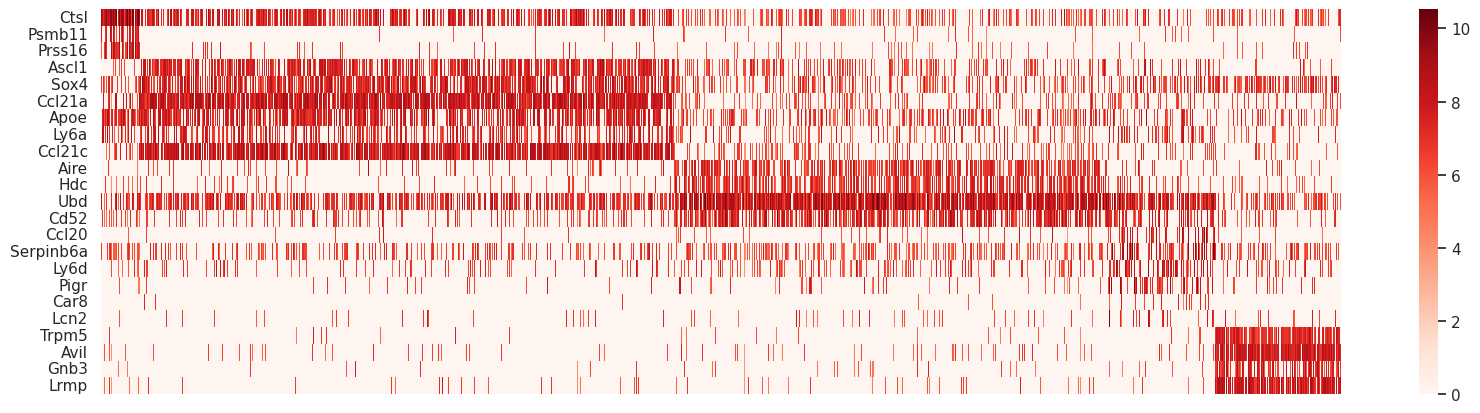

In [ ]:
# визуализация
f, ax = plt.subplots(figsize=(20, 5))
ax = sns.heatmap(np.log(counts.astype(np.float32) + 1), yticklabels=True, xticklabels=False, cmap='Reds')
plt.show()


На тепловой карте показан уровень экспрессии исследованных маркерных генов. Благодаря сортировке по кластерам, которые определили авторы статьи, клетки упорядочены по их биологическому типу или состоянию. На тепловой карте все клетки одной группы стоят рядом, образуя блок с одинаковым уровнем экспрессии.

# Визуализация клеток на UMAP и PCA

In [24]:
# создаю объект AnnData из нормализованных данных
# counts_norm.T - транспонирование матрицы, тк формат для AnnData: клетки × гены
adata = ad.AnnData(counts.T)

# логарифмическое преобразование для стабилизации дисперсии и приближения данных к нормальному распределению
sc.pp.log1p(adata)

In [25]:
# cells_type_data - cell type provided by authors
adata.obs["cell_type"] = sorted_cell_groups.values

In [26]:
# PCA анализ
sc.pp.pca(adata, n_comps=12)

In [27]:
# список цветов
colors = ['red', 'green', 'black', 'pink', 'orange']
# ListedColormap - создает дискретную цветовую карту из указанных цветов
# get_cmap - преобразует объект ListedColormap в функцию
cmap = get_cmap(ListedColormap(colors))

/tmp/ipython-input-2592122136.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(ListedColormap(colors))


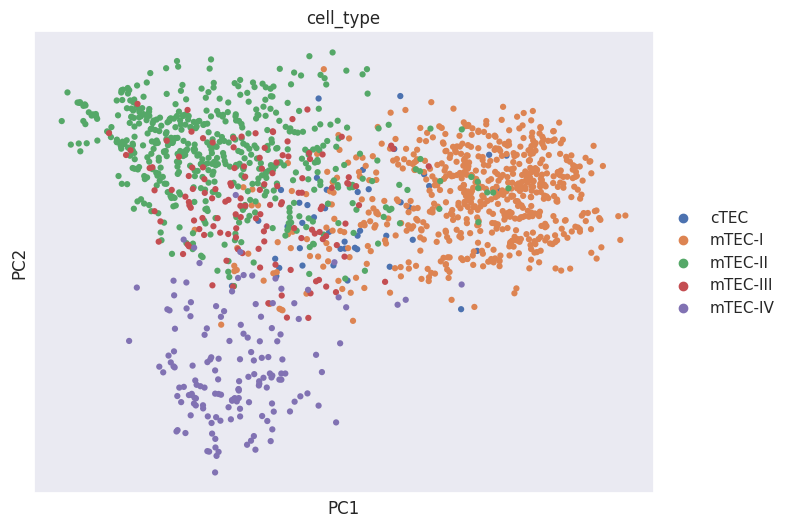

In [ ]:
# Визуализация PCA с окрашиванием по 'cell_type'
f, ax = plt.subplots(figsize=(8, 6))
sc.pl.pca(adata, color=['cell_type'], colorbar_loc=None, color_map=cmap, ax=ax)

Разные виды клеток образуют группы на графике, однако cTEC и mTEC-III не выделены также четко, как остальные группы. Распределение клеток в пространстве PCA отражает их биологические взаимосвязи.

In [28]:
# граф соседства клеток для кластеризации
# n_neighbors=10 - каждая клетка соединяется с 10 ближайшими соседями
# n_pcs=10 - используется 10 из 12 PCA компонент
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)

# UMAP
sc.tl.umap(adata)

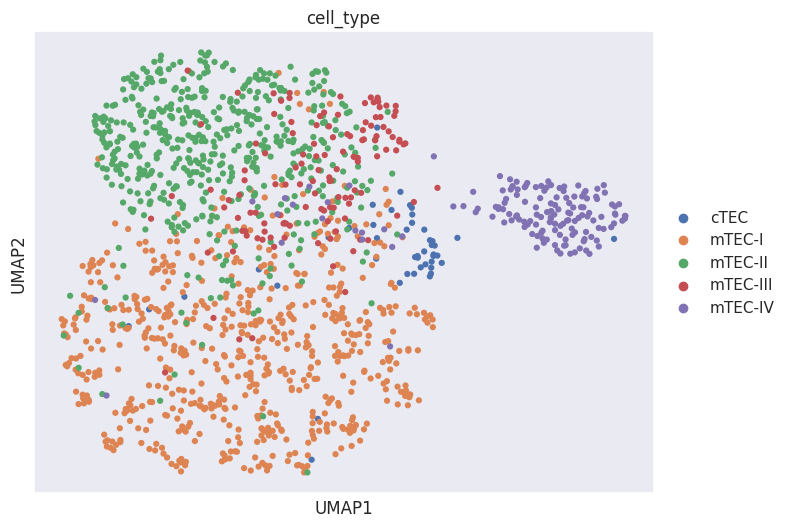

In [ ]:
# визуализация UMAP
f, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(adata, color=['cell_type'], colorbar_loc=None, color_map=cmap, ax=ax)
plt.show()

UMAP показывает более четкое разделение типов клеток по сравнению с PCA. Кластеры стали компактнее и лучше обособлены. Однако cTEC и mTEC-III по-прежнему остаются менее выделенными.

Экспрессия маркерных генов на UMAP

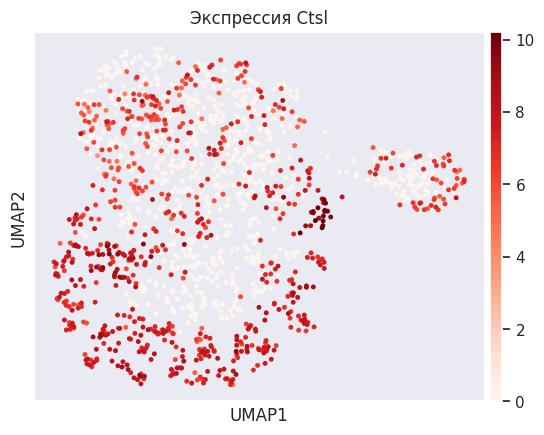

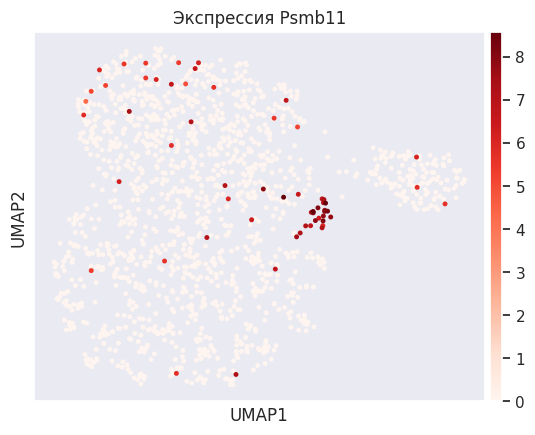

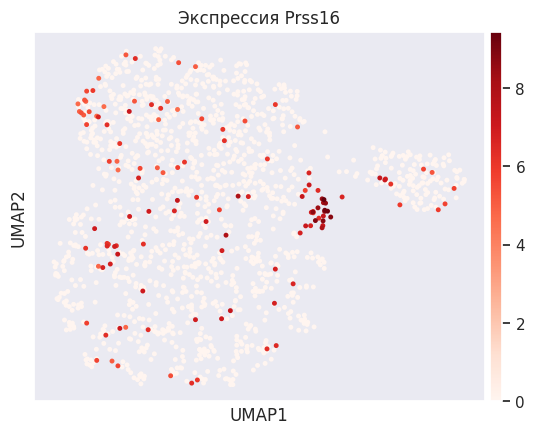

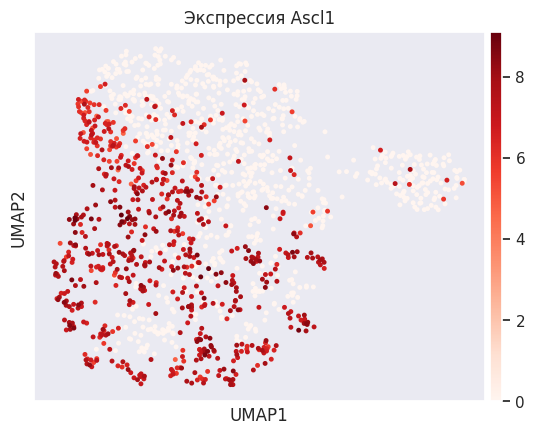

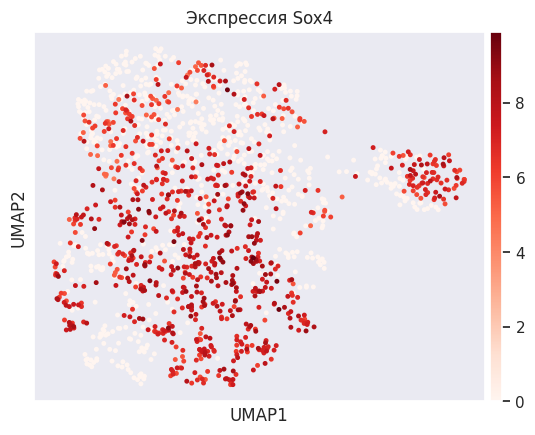

In [ ]:
for gene in markers[:5]:  # первые 5
    # UMAP с окрашиванием по экспрессии текущего гена
    # cmap='Reds' - красная цветовая схема
    # show=True - сразу показывать график
    # size=50 - размер точек на графике
  sc.pl.umap(adata, color=gene, title=f'Экспрессия {gene}',
                   cmap='Reds', show=True, size=50)

1.  Ген Ctsl: сильно экспрессированный ген, экспрессируется во всех кластерах, но наиболее сильно - в кластерах mTEC-I и cTEC

2.  Ген Psmb11: наиболее сильно экспрессирован в кластере cTEC

3.  Ген Prss16: есть экспрессия во всех кластерах, но в целом экспрессирован мало,наиболее сильно экспрессирован в кластере cTEC

4.  Ген Ascl1:  сильно экспрессированный ген, относится к кластеру mTEC-I

5.  Ген Sox4: самый экспрессированный ген из 5 представленных, экспрессируется во всех кластерах, но наиболее сильно в кластерах mTEC-I и mTEC-IV

# Вторая часть задания

In [13]:
# загружаю counts
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()

Saving SRR2038194.gene_name.counts to SRR2038194.gene_name.counts


Saving SRR2038195.gene_name.counts to SRR2038195.gene_name.counts


## Шаги 1-2. Нормализация bulk RNA-seq данных

In [14]:
!head -n 10 /content/SRR2038194.gene_name.counts


Gnai3	3767
Pbsn	0
Cdc45	281
H19	640
Scml2	58
Apoh	141
Narf	781
Cav2	200
Klf6	29846
Scmh1	316


In [38]:
# - sep='\t' - разделитель столбцов - табуляция
# - header=None - нет строки заголовка
# - names=['gene', 'count'] - имена столбцов 'gene' и 'count'

counts1 = pd.read_csv('SRR2038194.gene_name.counts', sep='\t', header=None, names=['gene', 'count'])
counts2 = pd.read_csv('SRR2038195.gene_name.counts', sep='\t', header=None, names=['gene', 'count'])

In [39]:
#CPM = (counts / total_counts) × 1,000,000
def cpm(counts_series):
    total = counts_series.sum()
    return (counts_series / total) * 1_000_000

# считаю cpm
cpm1 = cpm(counts1['count'])
cpm2 = cpm(counts2['count'])

# датафрейм
counts_cpm = pd.DataFrame({
    'gene': counts1['gene'],
    'SRR2038194_cpm': cpm1,
    'SRR2038195_cpm': cpm2
})

# беру среднее значение cpm по двум репликам bulk RNA-seq
counts_cpm['bulk_mean_cpm'] = counts_cpm[['SRR2038194_cpm', 'SRR2038195_cpm']].mean(axis=1)
counts_cpm = counts_cpm.drop(['SRR2038194_cpm', 'SRR2038195_cpm'], axis=1)

counts_cpm

,gene,bulk_mean_cpm
0,Gnai3,161.868203
1,Pbsn,0.062187
2,Cdc45,12.409779
3,H19,33.350970
4,Scml2,2.625019
...,...,...
55286,AC156032.1,0.053568
55287,BX681418.1,0.000000
55288,AL606917.1,0.046640
55289,CT485612.1,0.022475


In [40]:
bulk_df = counts_cpm.copy() # копия

# преобразую bulk в log1p (так как и scRNA-seq были так преобразованы)
bulk_df['bulk_mean_log_cpm'] = np.log1p(bulk_df['bulk_mean_cpm'])

bulk_df

,gene,bulk_mean_cpm,bulk_mean_log_cpm
0,Gnai3,161.868203,5.092941
1,Pbsn,0.062187,0.060330
2,Cdc45,12.409779,2.595984
3,H19,33.350970,3.536630
4,Scml2,2.625019,1.287860
...,...,...,...
55286,AC156032.1,0.053568,0.052183
55287,BX681418.1,0.000000,0.000000
55288,AL606917.1,0.046640,0.045585
55289,CT485612.1,0.022475,0.022226


## Шаг 3. Добавление данных scRNA seq

In [41]:
# нахожу клетки нужной подгруппы
mTEC_IV = adata.obs[adata.obs['cell_type'] == 'mTEC-IV'].index
print(f"Клеток mTEC-IV: {len(mTEC_IV)}")

# подмножество adata только для mTEC-IV
adata_mTEC_IV = adata[mTEC_IV]

Клеток mTEC-IV: 151


In [42]:
# среднее значение CPM по всем клеткам scRNA-seq (подгруппа  mTEC-IV)
sc_log_mean = adata_mTEC_IV.X.mean(axis=0)

sc_df = pd.DataFrame({
    'gene': adata_mTEC_IV.var_names,
    'sc_mean_log_cpm': sc_log_mean
})

sc_df

,gene,sc_mean_log_cpm
0,Ctsl,2.432946
1,Psmb11,0.116680
2,Prss16,0.490405
3,Ascl1,0.383541
4,Sox4,3.812343
5,Ccl21a,0.970152
6,Apoe,1.732513
7,Ly6a,0.862048
8,Ccl21c,0.809854
9,Aire,0.518662


##Шаг 4. Выборка для анализа (оставляю маркерные гены)

In [43]:
# сортирую bukl_df
# .isin() проверяет, находится ли значение в списке
bulk_markers = bulk_df[bulk_df['gene'].isin(markers)]

bulk_markers

,gene,bulk_mean_cpm,bulk_mean_log_cpm
113,Cd52,132.197147,4.891830
123,Aire,3000.208636,8.006770
513,Apoe,89.198460,4.502012
951,Prss16,64.114219,4.176143
1226,Trpm5,23.871055,3.213705
2278,Ascl1,230.623708,5.445114
3117,Ctsl,158.465332,5.071827
4132,Gnb3,12.412824,2.596211
5042,Avil,32.533420,3.512543
5389,Ccl20,56.930869,4.059250


In [45]:
# объединяю по колонке 'gene'
data_for_analysis = pd.merge(sc_df, bulk_markers[['gene', 'bulk_mean_log_cpm']], on='gene')

data_for_analysis

,gene,sc_mean_log_cpm,bulk_mean_log_cpm
0,Ctsl,2.432946,5.071827
1,Psmb11,0.116680,2.442589
2,Prss16,0.490405,4.176143
3,Ascl1,0.383541,5.445114
4,Sox4,3.812343,5.260634
5,Ccl21a,0.970152,0.022226
6,Apoe,1.732513,4.502012
7,Ly6a,0.862048,4.550049
8,Aire,0.518662,8.006770
9,Hdc,0.657795,7.112375


## Шаг 5. График

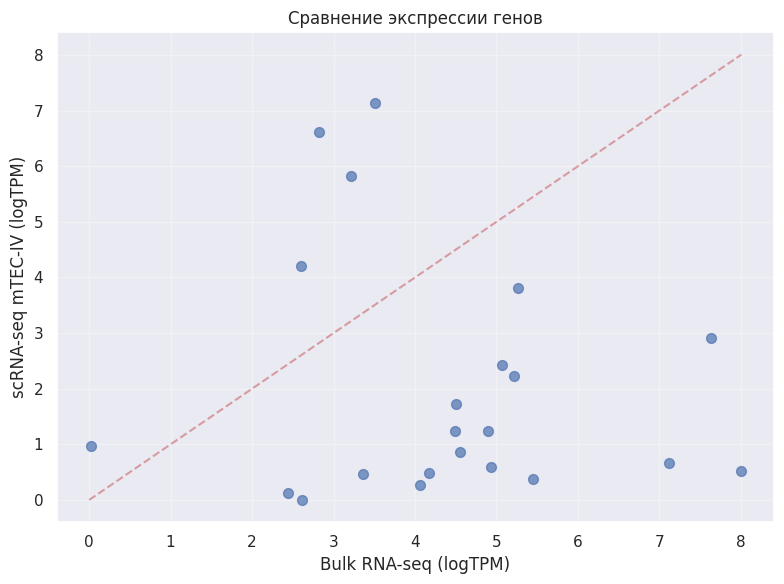

In [47]:
plt.figure(figsize=(8, 6))

# каждая точка = 1 ген
# X = средняя экспрессия в bulk
# Y = средняя экспрессия в mTEC-IV
plt.scatter(data_for_analysis['bulk_mean_log_cpm'],
            data_for_analysis['sc_mean_log_cpm'],
            s=50, alpha=0.7)

# линия y=x для сравнения
x_min = data_for_analysis['bulk_mean_log_cpm'].min()
x_max = data_for_analysis['bulk_mean_log_cpm'].max()
y_min = data_for_analysis['sc_mean_log_cpm'].min()
y_max = data_for_analysis['sc_mean_log_cpm'].max()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)

# Подписи осей
plt.xlabel('Bulk RNA-seq (logTPM)')
plt.ylabel('scRNA-seq mTEC-IV (logTPM)')
plt.title('Сравнение экспрессии генов')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Вывод: большинство точек не лежат близко к диагонали, что указывает на разную экспрессию в bulk и scRNA. Большая часть генов, особенно в области высокой экспрессии, демонстрирует значительные отклонения от линии. Только 3-4 находятся относительно близко к линии.